# Code to generate RDMs for time averaged stimuli for review rebuttal

In [1]:
import numpy as np 
import h5py
from pathlib import Path 
import IPython.display as ipd 
import pickle 
%matplotlib inline 
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import scipy.stats as stats
import copy

/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


In [2]:
embeddings_path = '/om2/user/imgriff/projects/torch_2_aud_attn/acts_for_RDM_analysis/word_task_v10_main_feature_gain_config/word_task_v10_main_feature_gain_config_model_activations_0dB_time_avg.h5'

embeddings = h5py.File(embeddings_path, 'r')

In [3]:
layer_names = ['norm_coch_rep',
            'attn0',
            'conv_block_0_ln',
            'conv_block_0_relu',
            'hann_pool_0',
            'attn1',
            'conv_block_1_ln',
            'conv_block_1_relu',
            'hann_pool_1',
            'attn2',
            'conv_block_2_ln',
            'conv_block_2_relu',
            'hann_pool_2',
            'attn3',
            'conv_block_3_ln',
            'conv_block_3_relu',
            'hann_pool_3',
            'attn4',
            'conv_block_4_ln',
            'conv_block_4_relu',
            'hann_pool_4',
            'attn5',
            'conv_block_5_ln',
            'conv_block_5_relu',
            'hann_pool_5',
            'attn6',
            'conv_block_6_ln',
            'conv_block_6_relu',
            'hann_pool_6',
            'attnfc',
            'relufc']

signal_names = ['cue', 'target', 'same_sex_sig', 'diff_sex_sig', 'nat_scene_sig', 'mixture_same_sex', 'mixture_diff_sex', 'mixture_nat_scene']

attn_type = ['single_source', 'cued']

In [4]:
target_locs = embeddings['target_loc']
target_f0s = embeddings['target_f0']

In [5]:
target_f0s

<HDF5 dataset "target_f0": shape (1400,), type "<f4">

In [6]:
target_locs[0]

array([0., 0.], dtype=float32)

In [7]:
single_src_coch_reps = embeddings['norm_coch_rep_target_single_source']
print(single_src_coch_reps.shape)

(1400, 80)


In [8]:
unique_locs = np.unique(target_locs, axis=0)

loc_to_idx = {}
# create map of unique locations to index
for loc in unique_locs:
    rows = np.where(np.all(target_locs == loc, axis=1))[0]
    loc_to_idx[tuple(loc)] = rows

/tmp/ipykernel_1436069/3426988523.py:6: DeprecationWarning: `product` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `prod` instead.
  rows = np.where(np.all(target_locs == loc, axis=1))[0]


In [10]:
def pearson_r(X, Y):
    X = np.asarray(X)
    Y = np.asarray(Y)
    if X.shape != Y.shape:
        raise ValueError(f"Shape mismatch: X{X.shape} vs Y{Y.shape}")

    Xc = X - X.mean(axis=1, keepdims=True)
    Yc = Y - Y.mean(axis=1, keepdims=True)

    Xnorm = np.linalg.norm(Xc, axis=1)
    Ynorm = np.linalg.norm(Yc, axis=1)
    denom = Xnorm * Ynorm

    num = np.sum(Xc * Yc, axis=1)

    with np.errstate(invalid='ignore', divide='ignore'):
        r_rows = num / denom
    r_rows[denom == 0] = np.nan

    # average over valid rows
    if np.all(np.isnan(r_rows)):
        return np.nan
    return np.nanmean(r_rows)


def l2_dist(X, Y):
    X = np.asarray(X)
    Y = np.asarray(Y)
    if X.shape != Y.shape:
        raise ValueError(f"Shape mismatch: X{X.shape} vs Y{Y.shape}")
    diffs = X - Y                       # (N, D)
    row_norms = np.linalg.norm(diffs, axis=1)  # (N,)
    return float(row_norms.mean())


def plot_lower_triangle(matrix, title, loc_labels, cmap='viridis'):
    mask = ~np.tril(np.ones_like(matrix, dtype=bool), k=-1)
    masked = np.ma.masked_array(matrix, mask=mask)
    plt.figure(figsize=(10, 10))
    im = plt.imshow(masked, cmap=cmap, vmin=np.nanmin(masked), vmax=np.nanmax(masked))
    plt.colorbar(im)
    plt.xticks(np.arange(len(loc_labels)), loc_labels, rotation=45, ha='right')
    plt.yticks(np.arange(len(loc_labels)), loc_labels)
    plt.title(title, fontsize=16, pad=20)
    plt.xlabel("Location")
    plt.ylabel("Location")
    plt.tight_layout()
    plt.show()

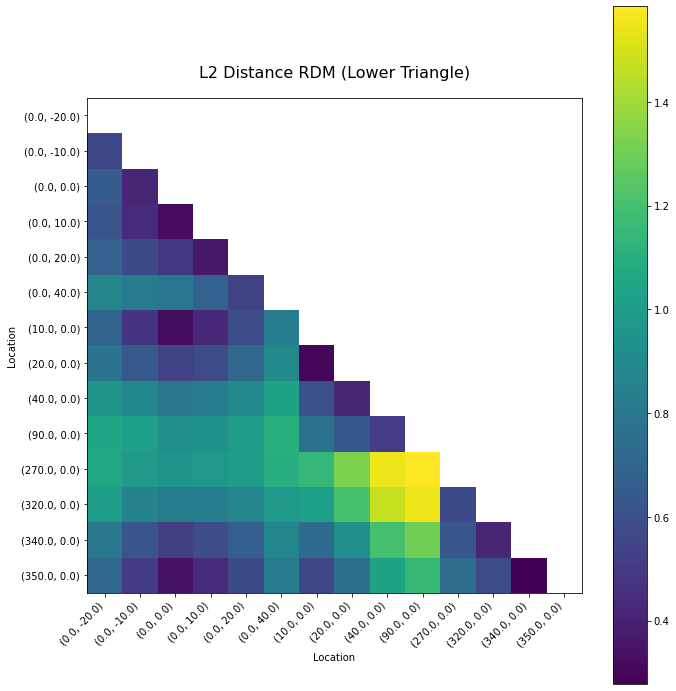

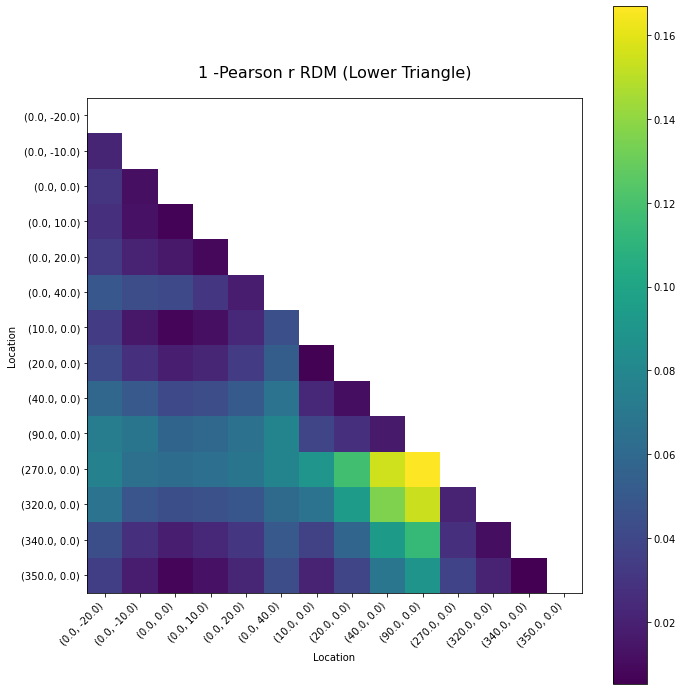

In [11]:
# plot the rdms, for representations for locations

# --- collect locations ---
all_locs = list(loc_to_idx.keys())

n = len(all_locs)
sing_source_pearson_r_matrix = np.full((n, n), np.nan, dtype=float)
sing_source_l2_dist_matrix  = np.full((n, n), np.nan, dtype=float)

for i in range(n):
    Xi = single_src_coch_reps[loc_to_idx[all_locs[i]]]  # (N, D)
    sing_source_pearson_r_matrix[i, i] = 1.0
    sing_source_l2_dist_matrix[i, i]   = 0.0
    for j in range(i):
        Xj = single_src_coch_reps[loc_to_idx[all_locs[j]]]  # (N, D)
        r  = pearson_r(Xi, Xj)
        d  = l2_dist(Xi, Xj)
        sing_source_pearson_r_matrix[i, j] = sing_source_pearson_r_matrix[j, i] = 1 - r
        sing_source_l2_dist_matrix[i, j]   = sing_source_l2_dist_matrix[j, i]   = d

loc_labels = [str(loc) for loc in all_locs]



plot_lower_triangle(sing_source_l2_dist_matrix,   "L2 Distance RDM (Lower Triangle)",   loc_labels, cmap='viridis')
plot_lower_triangle(sing_source_pearson_r_matrix, "1 -Pearson r RDM (Lower Triangle)",     loc_labels, cmap='viridis')


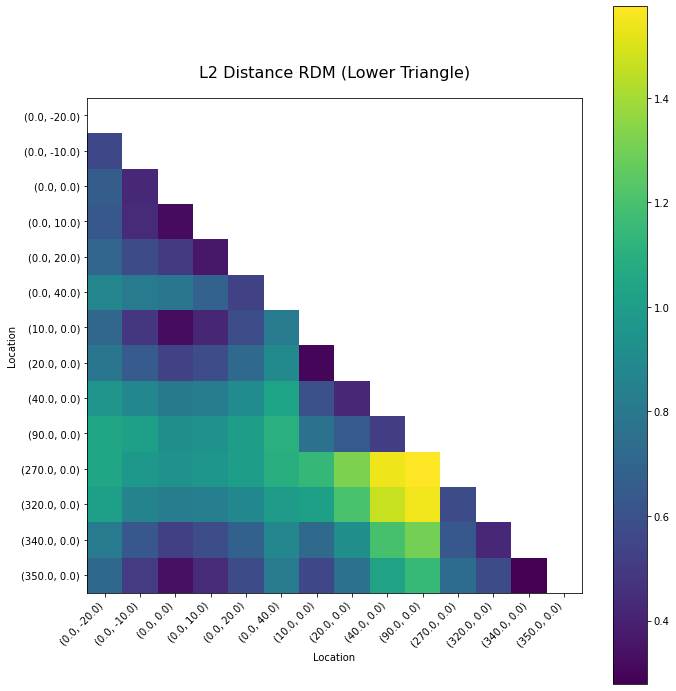

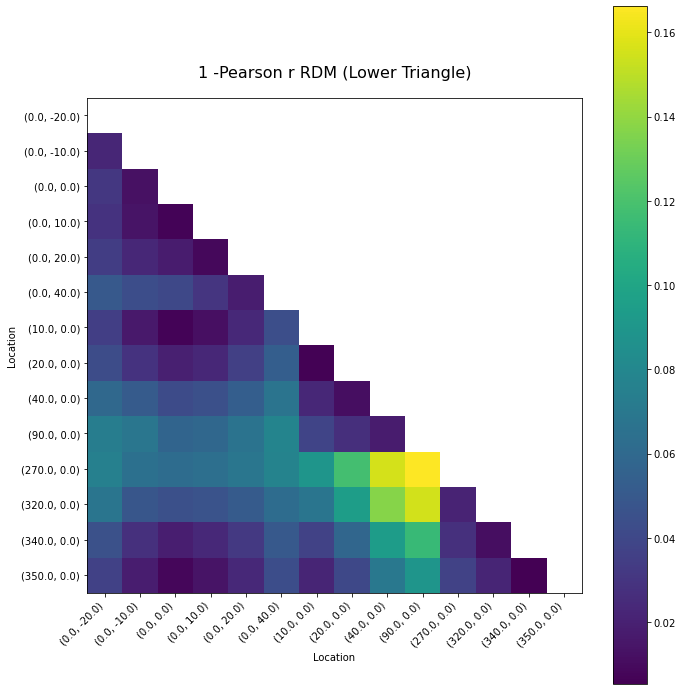

In [12]:
diff_talker_reps = embeddings['norm_coch_rep_diff_sex_sig_single_source']

n = len(all_locs)
diff_sex_pearson_r_matrix = np.full((n, n), np.nan, dtype=float)
diff_sex_l2_dist_matrix  = np.full((n, n), np.nan, dtype=float)

for i in range(n):
    Xi = diff_talker_reps[loc_to_idx[all_locs[i]]]  # (N, D)
    diff_sex_pearson_r_matrix[i, i] = 1.0
    diff_sex_l2_dist_matrix[i, i]   = 0.0
    for j in range(i):
        Xj = diff_talker_reps[loc_to_idx[all_locs[j]]]  # (N, D)
        r  = pearson_r(Xi, Xj)
        d  = l2_dist(Xi, Xj)
        diff_sex_pearson_r_matrix[i, j] = diff_sex_pearson_r_matrix[j, i] = 1 - r
        diff_sex_l2_dist_matrix[i, j]   = diff_sex_l2_dist_matrix[j, i]   = d

loc_labels = [str(loc) for loc in all_locs]

plot_lower_triangle(diff_sex_l2_dist_matrix,   "L2 Distance RDM (Lower Triangle)",   loc_labels, cmap='viridis')
plot_lower_triangle(diff_sex_pearson_r_matrix, "1 -Pearson r RDM (Lower Triangle)",     loc_labels, cmap='viridis')

## Making full cross RDMS for single source

In [34]:
def optimal_bin_count(data, min_bins=1, max_bins=50):
    # Calculate the Freedman-Diaconis bin width
    q25, q75 = np.percentile(data, [25, 75])
    bin_width = 2 * (q75 - q25) * len(data) ** (-1/3)
    bin_width = max(bin_width, 1e-5)  # Ensure bin width is not zero

    # Calculate the range of bin counts to test
    data_range = np.ptp(data)
    min_bins = max(min_bins, int(np.ceil(data_range / bin_width)))
    max_bins = min(max_bins, int(np.floor(data_range / bin_width)))

    best_bin_count = min_bins
    best_variance = float('inf')

    # Iterate over the range of bin counts
    for bins in range(min_bins, max_bins + 1):
        counts, _ = np.histogram(data, bins=bins)
        variance = np.var(counts)
        if variance < best_variance:
            best_variance = variance
            best_bin_count = bins

    return best_bin_count

optimal_bins = optimal_bin_count(target_f0s)
print(f"Optimal number of bins: {optimal_bins}")

Optimal number of bins: 14


In [49]:
# turn target f0s into 5 bin values using np.digitize with 5 bins from 85 Hz to 266 Hz
n_bins = 5
bin_edges = np.linspace(85, 266, n_bins + 1)  # 6 edges for 5 bins
# np.digitize returns bins 1..n_bins, matching np.digitize convention
target_f0s_bins = np.digitize(target_f0s, bin_edges[1:-1], right=False) + 1

In [50]:
# label each example with its location and bin, so that each bin and location is it's own example for the RDMS
# Combine target_f0s_bins and target_locs into a 2D array of shape (N, loc_dim+1)
all_crossed = np.concatenate(
    [target_f0s_bins[:, None], target_locs], axis=1
)

# Find all unique (bin, loc) pairs
unique_pairs = np.unique(all_crossed, axis=0)

loc_and_bin_to_idx = {}
# For each unique (bin, loc) pair, find the indices of all examples with that pair
for pair in unique_pairs:
    # pair[0] is bin, pair[1:] is loc
    mask = np.all(all_crossed == pair, axis=1)
    rows = np.where(mask)[0]
    loc_and_bin_to_idx[tuple(pair)] = rows

/tmp/ipykernel_1436069/3403427771.py:3: DeprecationWarning: `product` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `prod` instead.
  all_crossed = np.concatenate(


In [52]:
def one_d_pearson_r(X, Y):
    X = np.asarray(X)
    Y = np.asarray(Y)
    if X.shape != Y.shape:
        raise ValueError(f"Shape mismatch: X{X.shape} vs Y{Y.shape}")
    return np.corrcoef(X, Y)[0, 1]

def one_d_l2_dist(X, Y):
    X = np.asarray(X)
    Y = np.asarray(Y)
    if X.shape != Y.shape:
        raise ValueError(f"Shape mismatch: X{X.shape} vs Y{Y.shape}")
    return np.linalg.norm(X - Y)

In [58]:
# Helper to mask upper triangle and diagonal
def get_lower_triangle_mask(matrix):
    mask = ~np.tril(np.ones_like(matrix, dtype=bool), k=-1)
    return mask

all_locs_and_bins = list(loc_and_bin_to_idx.keys())
n = len(all_locs_and_bins)
loc_labels = [str(loc) for loc in all_locs_and_bins]

layers_of_interest = [
    'norm_coch_rep', 'conv_block_0_relu', 'conv_block_1_relu', 'conv_block_2_relu',
    'conv_block_3_relu', 'conv_block_4_relu', 'conv_block_5_relu', 'conv_block_6_relu', 'relufc'
]

# Precompute all RDMs for all layers, normalizing each matrix so its max is 1 (excluding diagonal for L2, and for Pearson)
l2_rdms = []
pearson_rdms = []
for layer in layers_of_interest:
    layer_reps = embeddings[f'{layer}_target_single_source']
    pearson_r_matrix = np.full((n, n), np.nan, dtype=float)
    l2_dist_matrix  = np.full((n, n), np.nan, dtype=float)
    for i in range(n):
        Xi = layer_reps[loc_and_bin_to_idx[all_locs_and_bins[i]]]  # (N, D)
        Xi = Xi.mean(axis=0) # (D,)
        pearson_r_matrix[i, i] = 1.0
        l2_dist_matrix[i, i]   = 0.0
        for j in range(i):
            Xj = layer_reps[loc_and_bin_to_idx[all_locs_and_bins[j]]]  # (N, D)
            Xj = Xj.mean(axis=0) # (D,)
            r  = one_d_pearson_r(Xi, Xj)
            d  = one_d_l2_dist(Xi, Xj)
            pearson_r_matrix[i, j] = pearson_r_matrix[j, i] = 1 - r
            l2_dist_matrix[i, j]   = l2_dist_matrix[j, i]   = d

    # Normalize L2 matrix (excluding diagonal)
    l2_mask = get_lower_triangle_mask(l2_dist_matrix)
    l2_vals = l2_dist_matrix[~l2_mask]
    l2_max = np.nanmax(l2_vals)
    if l2_max > 0:
        l2_dist_matrix = l2_dist_matrix / l2_max

    # Normalize Pearson matrix (excluding diagonal)
    pearson_mask = get_lower_triangle_mask(pearson_r_matrix)
    pearson_vals = pearson_r_matrix[~pearson_mask]
    pearson_max = np.nanmax(pearson_vals)
    if pearson_max > 0:
        pearson_r_matrix = pearson_r_matrix / pearson_max

    l2_rdms.append(l2_dist_matrix)
    pearson_rdms.append(pearson_r_matrix)

# Compute global vmin/vmax for each metric across all layers for consistent colorbars
def get_global_min_max(rdms, mask_func):
    vals = []
    for rdm in rdms:
        mask = mask_func(rdm)
        vals.append(np.ma.masked_array(rdm, mask=mask))
    all_vals = np.ma.concatenate([v.compressed() for v in vals])
    return np.nanmin(all_vals), np.nanmax(all_vals)

l2_vmin, l2_vmax = get_global_min_max(l2_rdms, get_lower_triangle_mask)
pearson_vmin, pearson_vmax = get_global_min_max(pearson_rdms, get_lower_triangle_mask)

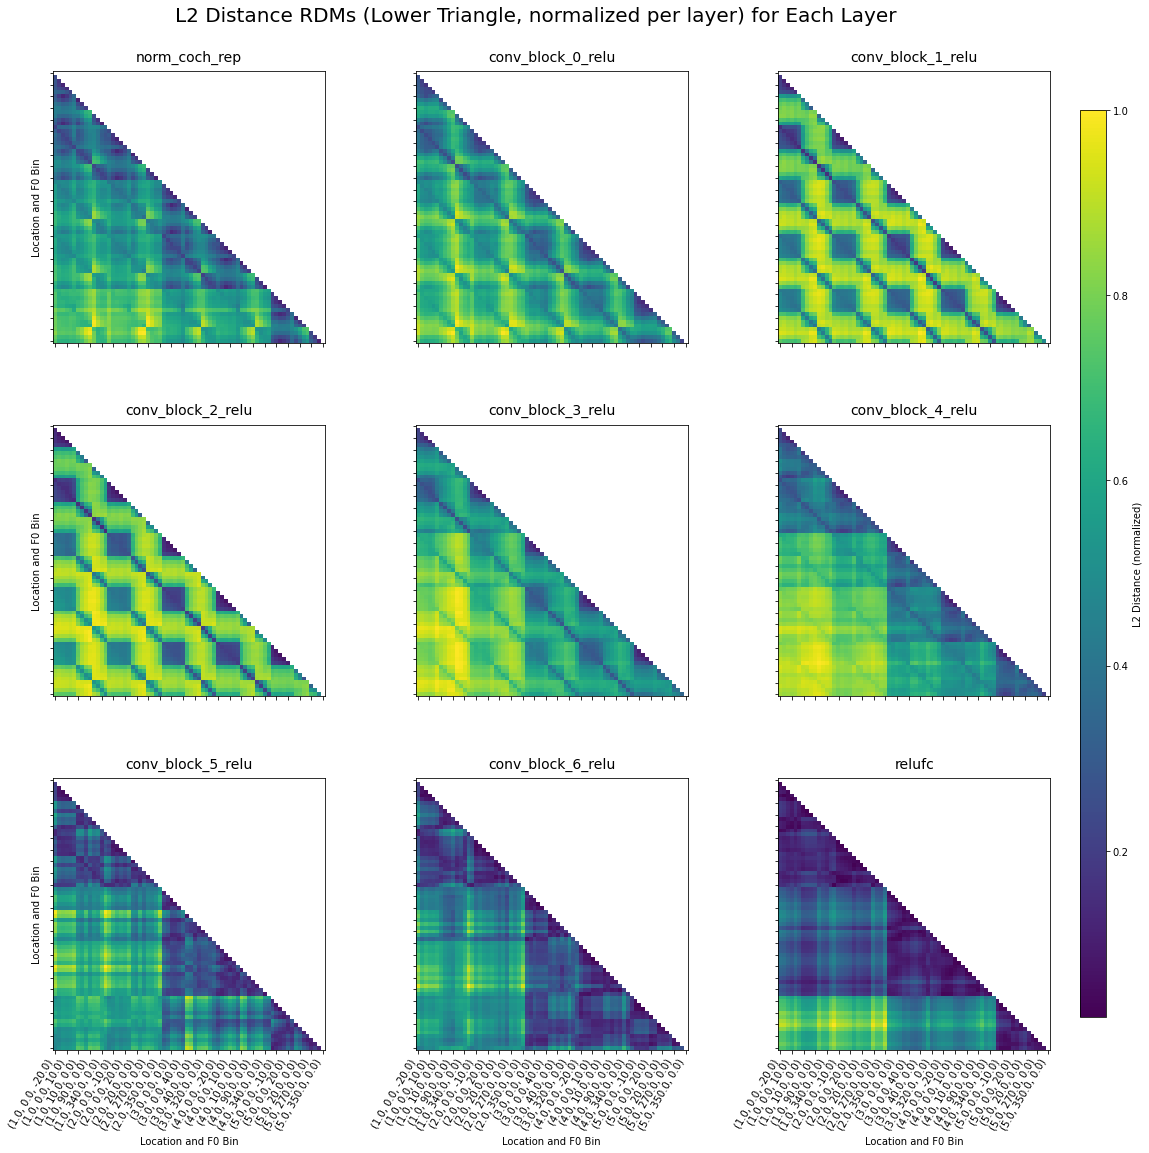

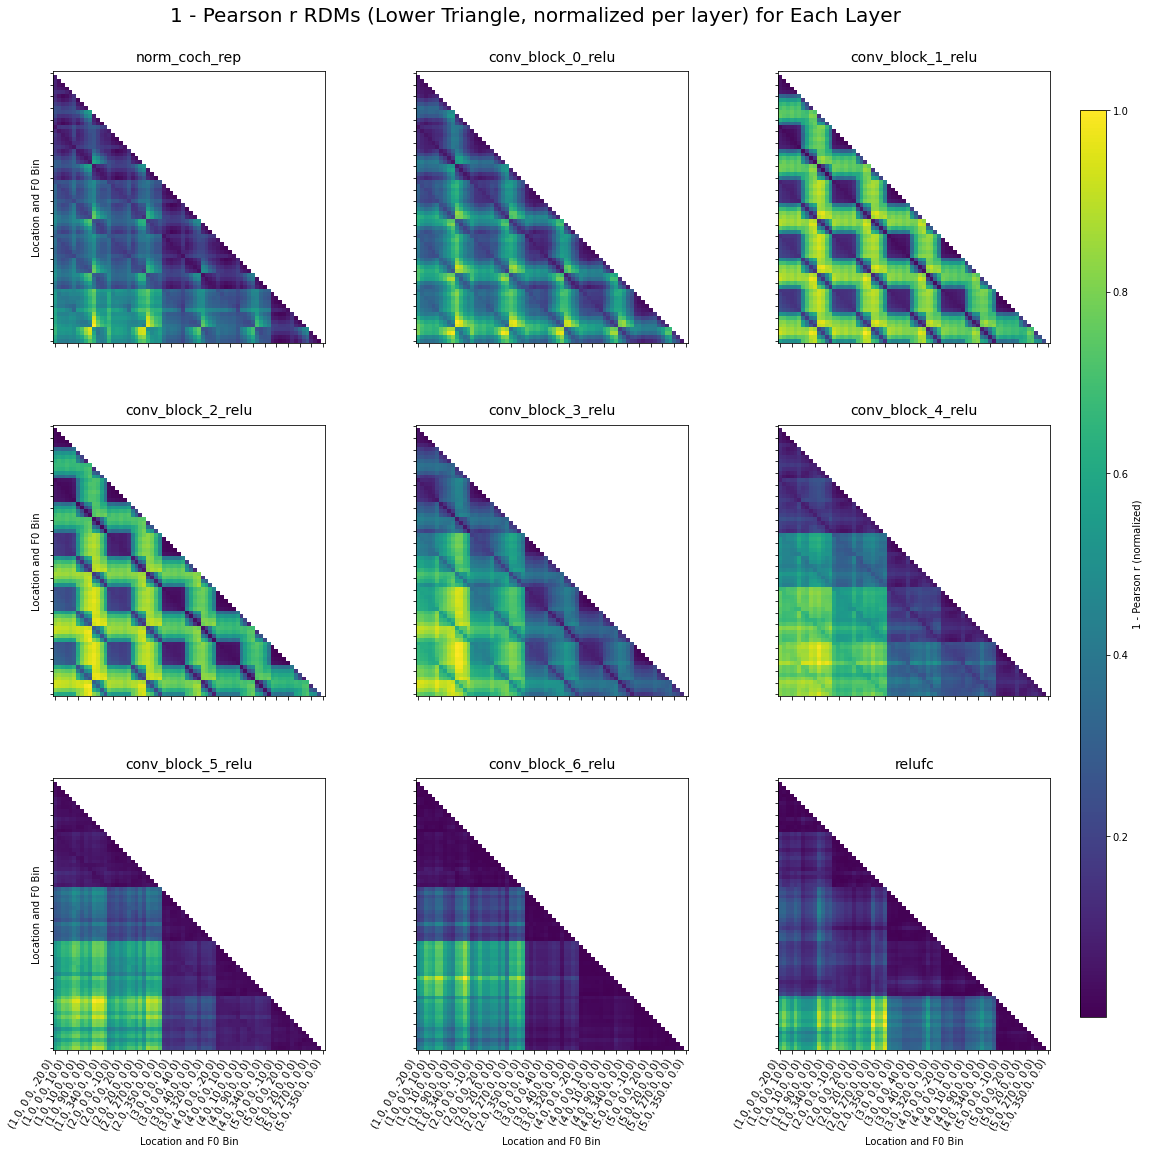

In [67]:
# Plot 3x3 grid: each row is a layer, left=L2, right=1-Pearson r
fig, axes = plt.subplots(3, 3, figsize=(18, 18), sharex=True, sharey=True)
plt.subplots_adjust(wspace=0.3, hspace=0.3)

for idx, layer in enumerate(layers_of_interest):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    # L2 on top, Pearson on bottom
    l2_rdm = l2_rdms[idx]
    pearson_rdm = pearson_rdms[idx]
    mask = get_lower_triangle_mask(l2_rdm)
    l2_masked = np.ma.masked_array(l2_rdm, mask=mask)
    pearson_masked = np.ma.masked_array(pearson_rdm, mask=mask)
    # Plot L2 in left column, Pearson in right column
    im = ax.imshow(l2_masked, cmap='viridis', vmin=l2_vmin, vmax=l2_vmax)
    # Overlay 1-Pearson r as a second image with a different colormap if desired
    # im2 = ax.imshow(pearson_masked, cmap='magma', vmin=pearson_vmin, vmax=pearson_vmax, alpha=0.5)
    ax.set_title(f"{layer}", fontsize=14, pad=10)
    if row == 2:
        ax.set_xticks(np.arange(len(loc_labels))[::3])
        ax.set_xticklabels(loc_labels[::3], rotation=60, ha='right', fontsize=10)
    else:
        ax.set_xticklabels([])
    if col == 0:
        ax.set_yticks(np.arange(len(loc_labels))[::3])
        ax.set_yticklabels(loc_labels[::3], fontsize=10)
    else:
        ax.set_yticklabels([])
    # Only label axes on left and bottom
    if row == 2:
        ax.set_xlabel("Location and F0 Bin")
    if col == 0:
        ax.set_ylabel("Location and F0 Bin")

# Add a single colorbar for L2
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label="L2 Distance (normalized)")

plt.suptitle("L2 Distance RDMs (Lower Triangle, normalized per layer) for Each Layer", fontsize=20, y=0.93)
plt.show()

# Now plot 3x3 grid for 1-Pearson r
fig, axes = plt.subplots(3, 3, figsize=(18, 18), sharex=True, sharey=True)
plt.subplots_adjust(wspace=0.3, hspace=0.3)

for idx, layer in enumerate(layers_of_interest):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    pearson_rdm = pearson_rdms[idx]
    mask = get_lower_triangle_mask(pearson_rdm)
    pearson_masked = np.ma.masked_array(pearson_rdm, mask=mask)
    im = ax.imshow(pearson_masked, cmap='viridis', vmin=pearson_vmin, vmax=pearson_vmax)
    ax.set_title(f"{layer}", fontsize=14, pad=10)
    if row == 2:
        ax.set_xticks(np.arange(len(loc_labels))[::3])
        ax.set_xticklabels(loc_labels[::3], rotation=60, ha='right', fontsize=10)
    else:
        ax.set_xticklabels([])
    if col == 0:
        ax.set_yticks(np.arange(len(loc_labels))[::3])
        ax.set_yticklabels(loc_labels[::3], fontsize=10)
    else:
        ax.set_yticklabels([])
    if row == 2:
        ax.set_xlabel("Location and F0 Bin")
    if col == 0:
        ax.set_ylabel("Location and F0 Bin")

# Add a single colorbar for 1-Pearson r
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label="1 - Pearson r (normalized)")

plt.suptitle("1 - Pearson r RDMs (Lower Triangle, normalized per layer) for Each Layer", fontsize=20, y=0.93)
plt.show()

# Making azim/elev RDMs with single source, and cued/uncued mixtures

In [68]:
all_locs = list(loc_to_idx.keys())
n = len(all_locs)

In [71]:
loc_labels = [str(loc) for loc in all_locs]

layers_of_interest = [
    'norm_coch_rep', 'conv_block_0_relu', 'conv_block_1_relu', 'conv_block_2_relu',
    'conv_block_3_relu', 'conv_block_4_relu', 'conv_block_5_relu', 'conv_block_6_relu', 'relufc'
]

# Precompute all RDMs for all layers, normalizing each matrix so its max is 1 (excluding diagonal for L2, and for Pearson)
l2_rdms = []
pearson_rdms = []
for layer in layers_of_interest:
    layer_reps = embeddings[f'{layer}_target_single_source']
    pearson_r_matrix = np.full((n, n), np.nan, dtype=float)
    l2_dist_matrix  = np.full((n, n), np.nan, dtype=float)
    for i in range(n):
        Xi = layer_reps[loc_to_idx[all_locs[i]]]  # (N, D)
        pearson_r_matrix[i, i] = 1.0
        l2_dist_matrix[i, i]   = 0.0
        for j in range(i):
            Xj = layer_reps[loc_to_idx[all_locs[j]]]  # (N, D)
            r  = pearson_r(Xi, Xj)
            d  = l2_dist(Xi, Xj)
            pearson_r_matrix[i, j] = pearson_r_matrix[j, i] = 1 - r
            l2_dist_matrix[i, j]   = l2_dist_matrix[j, i]   = d

    # Normalize L2 matrix (excluding diagonal)
    l2_mask = get_lower_triangle_mask(l2_dist_matrix)
    l2_vals = l2_dist_matrix[~l2_mask]
    l2_max = np.nanmax(l2_vals)
    if l2_max > 0:
        l2_dist_matrix = l2_dist_matrix / l2_max

    # Normalize Pearson matrix (excluding diagonal)
    pearson_mask = get_lower_triangle_mask(pearson_r_matrix)
    pearson_vals = pearson_r_matrix[~pearson_mask]
    pearson_max = np.nanmax(pearson_vals)
    if pearson_max > 0:
        pearson_r_matrix = pearson_r_matrix / pearson_max

    l2_rdms.append(l2_dist_matrix)
    pearson_rdms.append(pearson_r_matrix)

# Compute global vmin/vmax for each metric across all layers for consistent colorbars
def get_global_min_max(rdms, mask_func):
    vals = []
    for rdm in rdms:
        mask = mask_func(rdm)
        vals.append(np.ma.masked_array(rdm, mask=mask))
    all_vals = np.ma.concatenate([v.compressed() for v in vals])
    return np.nanmin(all_vals), np.nanmax(all_vals)

l2_vmin, l2_vmax = get_global_min_max(l2_rdms, get_lower_triangle_mask)
pearson_vmin, pearson_vmax = get_global_min_max(pearson_rdms, get_lower_triangle_mask)

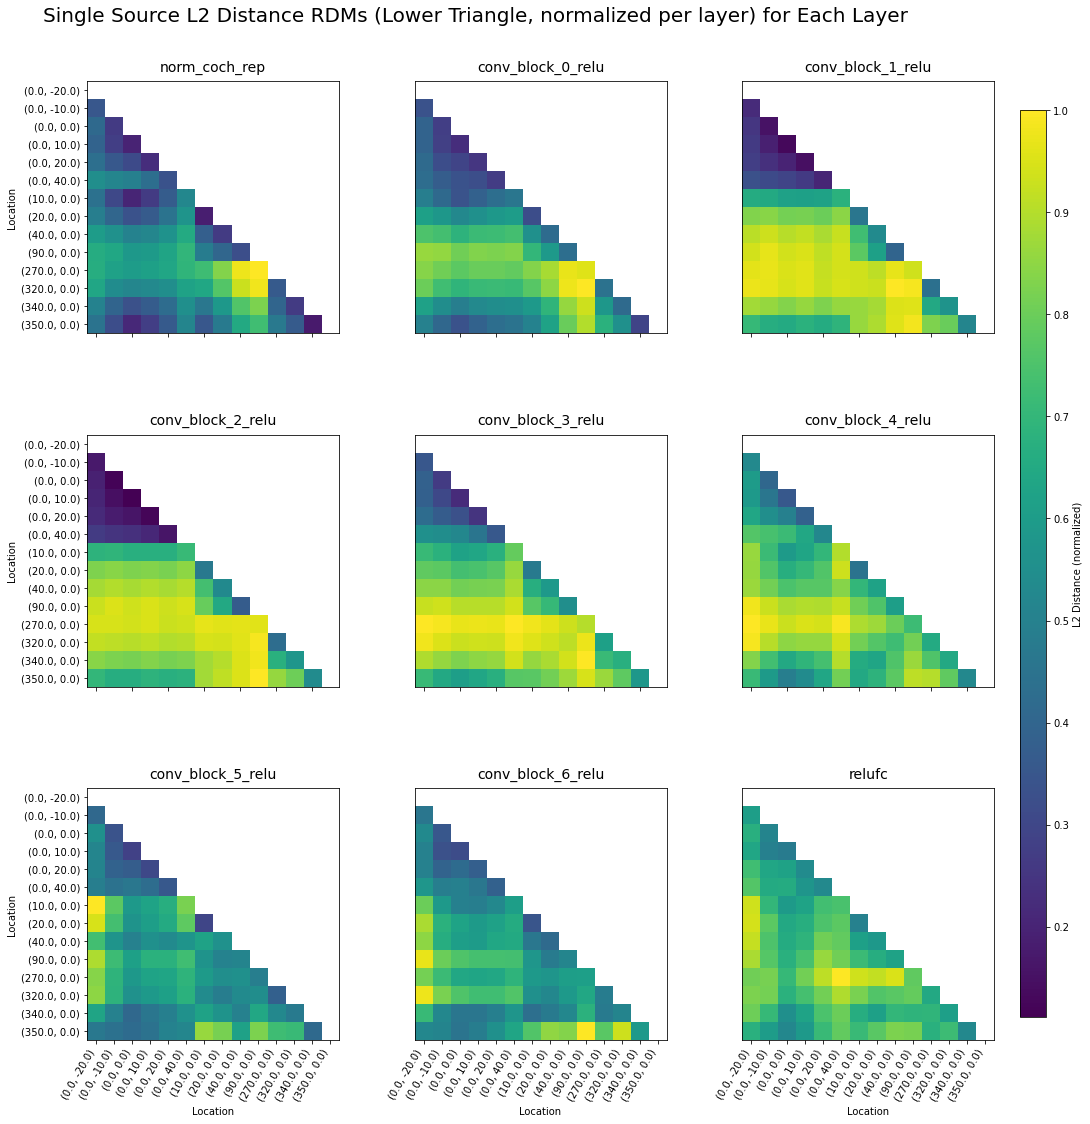

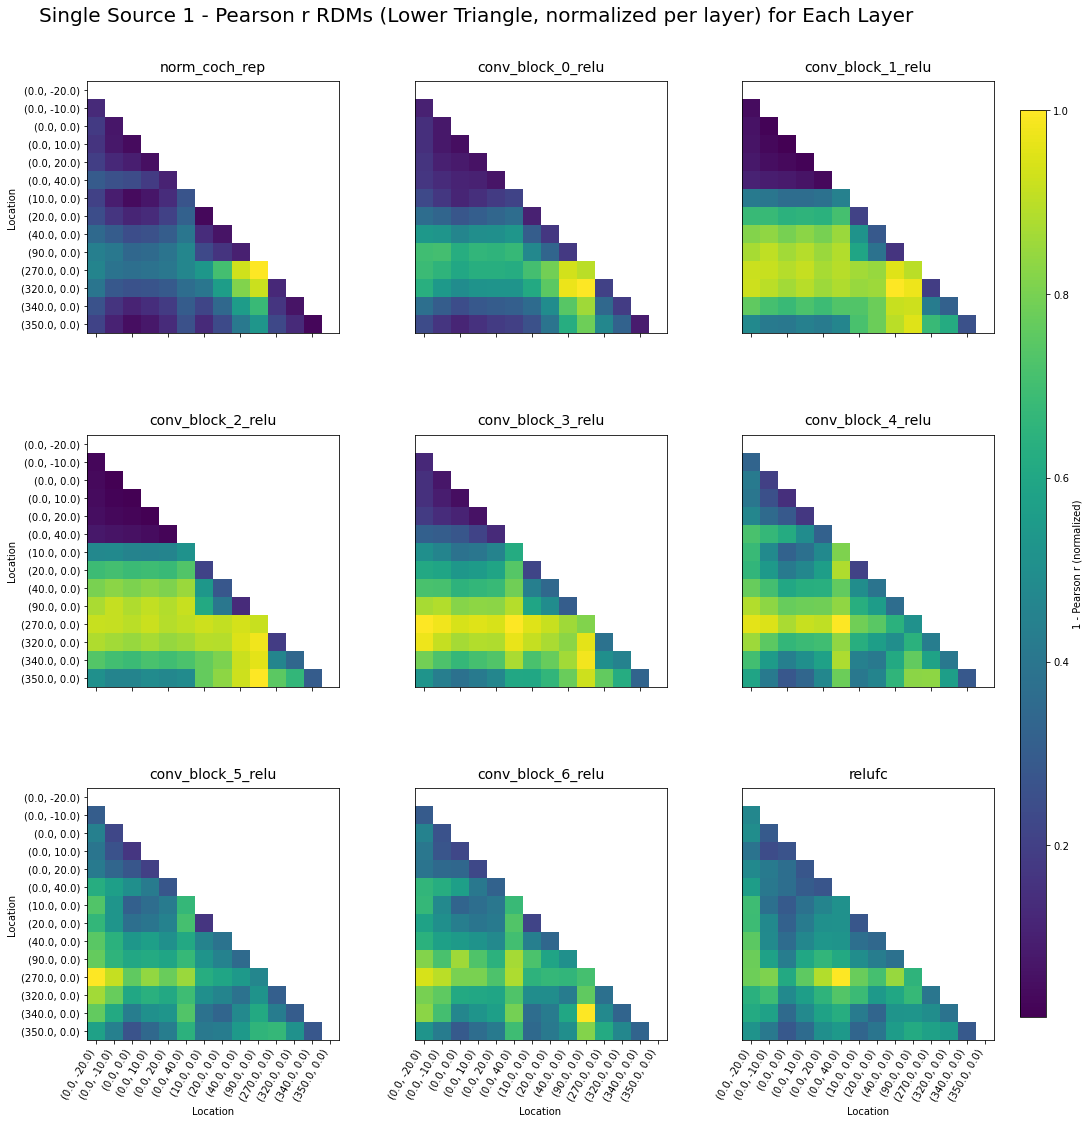

In [81]:
# Plot 3x3 grid: each row is a layer, left=L2, right=1-Pearson r
fig, axes = plt.subplots(3, 3, figsize=(18, 18))
plt.subplots_adjust(wspace=0.3, hspace=0.3, left=0.20)  # 2) make room on the left


for idx, layer in enumerate(layers_of_interest):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    # L2 on top, Pearson on bottom
    l2_rdm = l2_rdms[idx]
    pearson_rdm = pearson_rdms[idx]
    mask = get_lower_triangle_mask(l2_rdm)
    l2_masked = np.ma.masked_array(l2_rdm, mask=mask)
    pearson_masked = np.ma.masked_array(pearson_rdm, mask=mask)
    # Plot L2 in left column, Pearson in right column
    im = ax.imshow(l2_masked, cmap='viridis', vmin=l2_vmin, vmax=l2_vmax)
    # Overlay 1-Pearson r as a second image with a different colormap if desired
    # im2 = ax.imshow(pearson_masked, cmap='magma', vmin=pearson_vmin, vmax=pearson_vmax, alpha=0.5)
    ax.set_title(f"{layer}", fontsize=14, pad=10)
    if row == 2:
        ax.set_xticks(np.arange(len(loc_labels)))
        ax.set_xticklabels(loc_labels, rotation=60, ha='right', fontsize=10)
    else:
        ax.set_xticklabels([])
    # Always set y-ticks and y-ticklabels for first column
    if col == 0:
        ax.set_yticks(np.arange(len(loc_labels)))
        ax.set_yticklabels(loc_labels, fontsize=10)
    else:
        ax.set_yticks([])  # Hide y-ticks for other columns
        ax.set_yticklabels([])
        ax.tick_params(labelleft=True, left=True)
    # Only label axes on left and bottom
    if row == 2:
        ax.set_xlabel("Location")
    if col == 0:
        ax.set_ylabel("Location")

# Add a single colorbar for L2
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label="L2 Distance (normalized)")

plt.suptitle("Single Source L2 Distance RDMs (Lower Triangle, normalized per layer) for Each Layer", fontsize=20, y=0.93)
plt.show()

# Now plot 3x3 grid for 1-Pearson r
fig, axes = plt.subplots(3, 3, figsize=(18, 18) )
plt.subplots_adjust(wspace=0.3, hspace=0.3, left=0.20)  # 2) make room on the left

for idx, layer in enumerate(layers_of_interest):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    pearson_rdm = pearson_rdms[idx]
    mask = get_lower_triangle_mask(pearson_rdm)
    pearson_masked = np.ma.masked_array(pearson_rdm, mask=mask)
    im = ax.imshow(pearson_masked, cmap='viridis', vmin=pearson_vmin, vmax=pearson_vmax)
    ax.set_title(f"{layer}", fontsize=14, pad=10)
    if row == 2:
        ax.set_xticks(np.arange(len(loc_labels)))
        ax.set_xticklabels(loc_labels, rotation=60, ha='right', fontsize=10)
    else:
        ax.set_xticklabels([])
    # Always set y-ticks and y-ticklabels for first column
    if col == 0:
        ax.set_yticks(np.arange(len(loc_labels)))
        ax.set_yticklabels(loc_labels, fontsize=10)
        ax.tick_params(labelleft=True, left=True)
    else:
        ax.set_yticks([])  # Hide y-ticks for other columns
        ax.set_yticklabels([])
    if row == 2:
        ax.set_xlabel("Location")
    if col == 0:
        ax.set_ylabel("Location")

# Add a single colorbar for 1-Pearson r
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label="1 - Pearson r (normalized)")

plt.suptitle("Single Source 1 - Pearson r RDMs (Lower Triangle, normalized per layer) for Each Layer", fontsize=20, y=0.93)
plt.show()

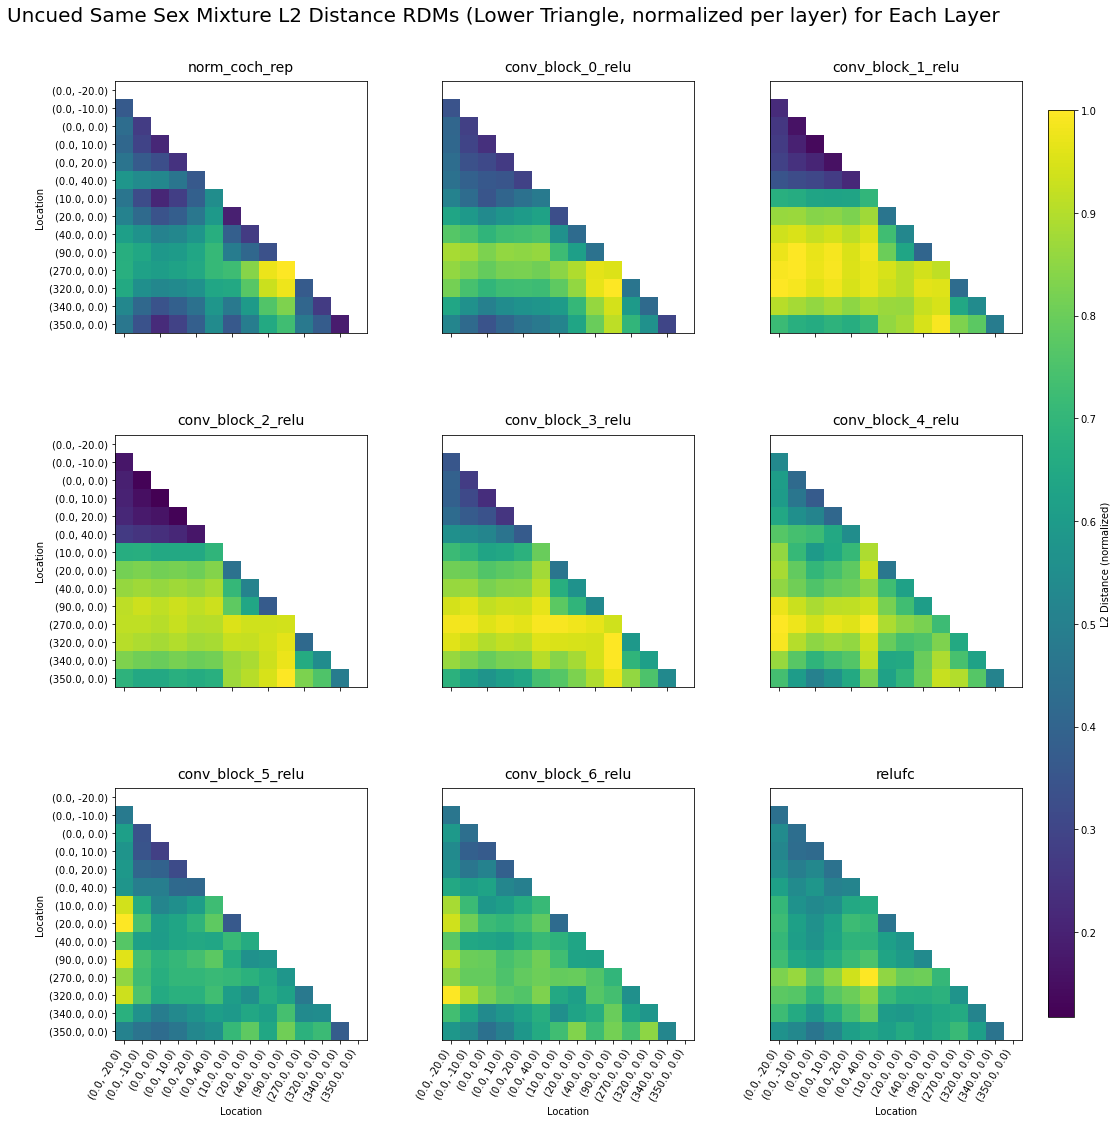

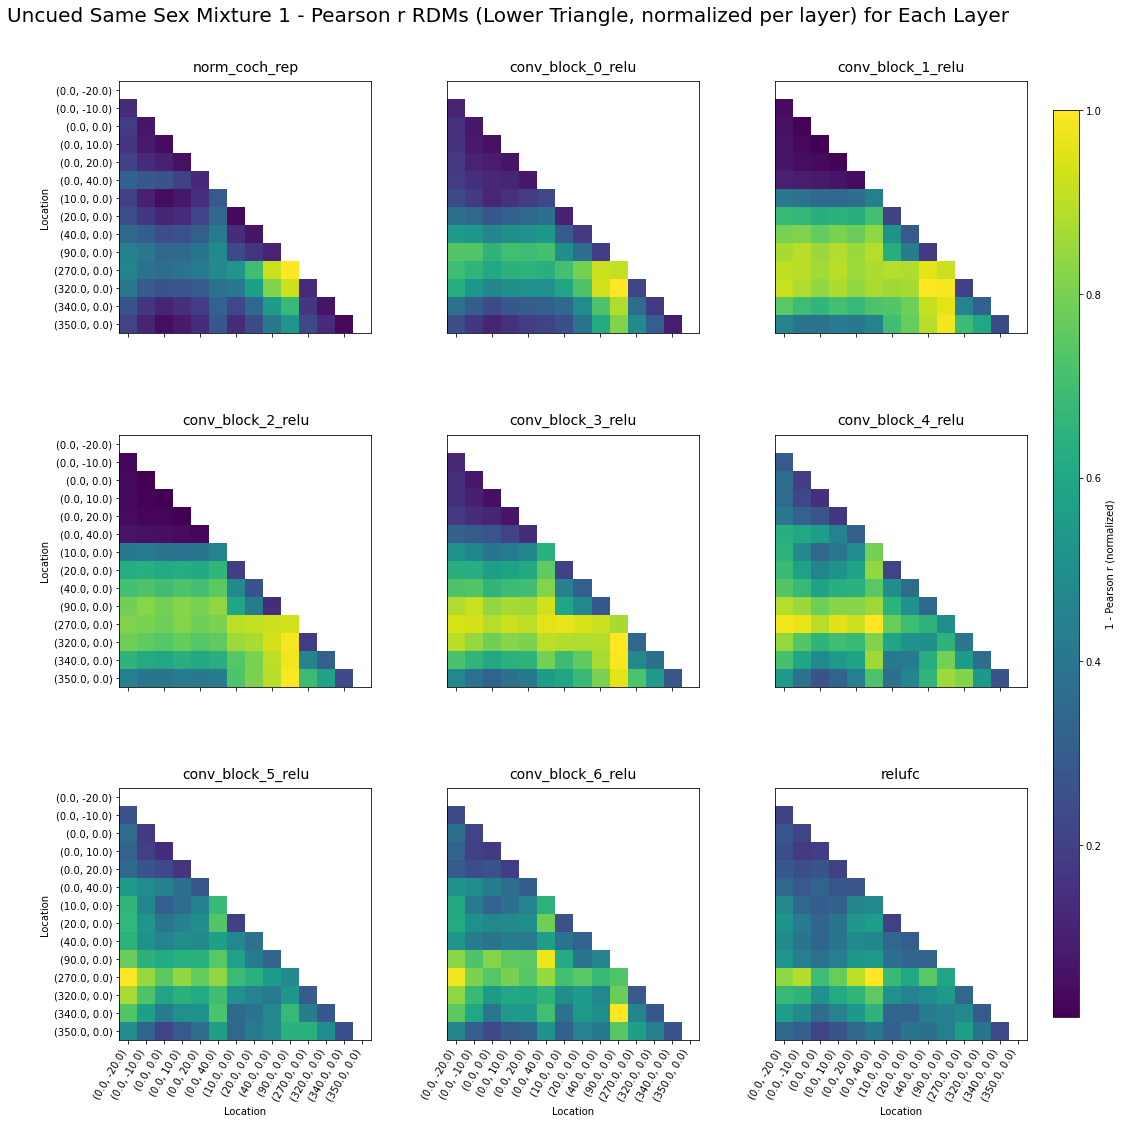

In [82]:
loc_labels = [str(loc) for loc in all_locs]

layers_of_interest = [
    'norm_coch_rep', 'conv_block_0_relu', 'conv_block_1_relu', 'conv_block_2_relu',
    'conv_block_3_relu', 'conv_block_4_relu', 'conv_block_5_relu', 'conv_block_6_relu', 'relufc'
]

# Precompute all RDMs for all layers, normalizing each matrix so its max is 1 (excluding diagonal for L2, and for Pearson)
l2_rdms = []
pearson_rdms = []
for layer in layers_of_interest:
    layer_reps = embeddings[f'{layer}_mixture_same_sex_single_source']
    pearson_r_matrix = np.full((n, n), np.nan, dtype=float)
    l2_dist_matrix  = np.full((n, n), np.nan, dtype=float)
    for i in range(n):
        Xi = layer_reps[loc_to_idx[all_locs[i]]]  # (N, D)
        pearson_r_matrix[i, i] = 1.0
        l2_dist_matrix[i, i]   = 0.0
        for j in range(i):
            Xj = layer_reps[loc_to_idx[all_locs[j]]]  # (N, D)
            r  = pearson_r(Xi, Xj)
            d  = l2_dist(Xi, Xj)
            pearson_r_matrix[i, j] = pearson_r_matrix[j, i] = 1 - r
            l2_dist_matrix[i, j]   = l2_dist_matrix[j, i]   = d

    # Normalize L2 matrix (excluding diagonal)
    l2_mask = get_lower_triangle_mask(l2_dist_matrix)
    l2_vals = l2_dist_matrix[~l2_mask]
    l2_max = np.nanmax(l2_vals)
    if l2_max > 0:
        l2_dist_matrix = l2_dist_matrix / l2_max

    # Normalize Pearson matrix (excluding diagonal)
    pearson_mask = get_lower_triangle_mask(pearson_r_matrix)
    pearson_vals = pearson_r_matrix[~pearson_mask]
    pearson_max = np.nanmax(pearson_vals)
    if pearson_max > 0:
        pearson_r_matrix = pearson_r_matrix / pearson_max

    l2_rdms.append(l2_dist_matrix)
    pearson_rdms.append(pearson_r_matrix)

# Compute global vmin/vmax for each metric across all layers for consistent colorbars
def get_global_min_max(rdms, mask_func):
    vals = []
    for rdm in rdms:
        mask = mask_func(rdm)
        vals.append(np.ma.masked_array(rdm, mask=mask))
    all_vals = np.ma.concatenate([v.compressed() for v in vals])
    return np.nanmin(all_vals), np.nanmax(all_vals)

l2_vmin, l2_vmax = get_global_min_max(l2_rdms, get_lower_triangle_mask)
pearson_vmin, pearson_vmax = get_global_min_max(pearson_rdms, get_lower_triangle_mask)

# Plot 3x3 grid: each row is a layer, left=L2, right=1-Pearson r
fig, axes = plt.subplots(3, 3, figsize=(18, 18))
plt.subplots_adjust(wspace=0.3, hspace=0.3, left=0.20)  # 2) make room on the left


for idx, layer in enumerate(layers_of_interest):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    # L2 on top, Pearson on bottom
    l2_rdm = l2_rdms[idx]
    pearson_rdm = pearson_rdms[idx]
    mask = get_lower_triangle_mask(l2_rdm)
    l2_masked = np.ma.masked_array(l2_rdm, mask=mask)
    pearson_masked = np.ma.masked_array(pearson_rdm, mask=mask)
    # Plot L2 in left column, Pearson in right column
    im = ax.imshow(l2_masked, cmap='viridis', vmin=l2_vmin, vmax=l2_vmax)
    # Overlay 1-Pearson r as a second image with a different colormap if desired
    # im2 = ax.imshow(pearson_masked, cmap='magma', vmin=pearson_vmin, vmax=pearson_vmax, alpha=0.5)
    ax.set_title(f"{layer}", fontsize=14, pad=10)
    if row == 2:
        ax.set_xticks(np.arange(len(loc_labels)))
        ax.set_xticklabels(loc_labels, rotation=60, ha='right', fontsize=10)
    else:
        ax.set_xticklabels([])
    # Always set y-ticks and y-ticklabels for first column
    if col == 0:
        ax.set_yticks(np.arange(len(loc_labels)))
        ax.set_yticklabels(loc_labels, fontsize=10)
    else:
        ax.set_yticks([])  # Hide y-ticks for other columns
        ax.set_yticklabels([])
        ax.tick_params(labelleft=True, left=True)
    # Only label axes on left and bottom
    if row == 2:
        ax.set_xlabel("Location")
    if col == 0:
        ax.set_ylabel("Location")

# Add a single colorbar for L2
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label="L2 Distance (normalized)")

plt.suptitle("Uncued Same Sex Mixture L2 Distance RDMs (Lower Triangle, normalized per layer) for Each Layer", fontsize=20, y=0.93)
plt.show()

# Now plot 3x3 grid for 1-Pearson r
fig, axes = plt.subplots(3, 3, figsize=(18, 18) )
plt.subplots_adjust(wspace=0.3, hspace=0.3, left=0.20)  # 2) make room on the left

for idx, layer in enumerate(layers_of_interest):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    pearson_rdm = pearson_rdms[idx]
    mask = get_lower_triangle_mask(pearson_rdm)
    pearson_masked = np.ma.masked_array(pearson_rdm, mask=mask)
    im = ax.imshow(pearson_masked, cmap='viridis', vmin=pearson_vmin, vmax=pearson_vmax)
    ax.set_title(f"{layer}", fontsize=14, pad=10)
    if row == 2:
        ax.set_xticks(np.arange(len(loc_labels)))
        ax.set_xticklabels(loc_labels, rotation=60, ha='right', fontsize=10)
    else:
        ax.set_xticklabels([])
    # Always set y-ticks and y-ticklabels for first column
    if col == 0:
        ax.set_yticks(np.arange(len(loc_labels)))
        ax.set_yticklabels(loc_labels, fontsize=10)
        ax.tick_params(labelleft=True, left=True)
    else:
        ax.set_yticks([])  # Hide y-ticks for other columns
        ax.set_yticklabels([])
    if row == 2:
        ax.set_xlabel("Location")
    if col == 0:
        ax.set_ylabel("Location")

# Add a single colorbar for 1-Pearson r
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label="1 - Pearson r (normalized)")

plt.suptitle("Uncued Same Sex Mixture 1 - Pearson r RDMs (Lower Triangle, normalized per layer) for Each Layer", fontsize=20, y=0.93)
plt.show()

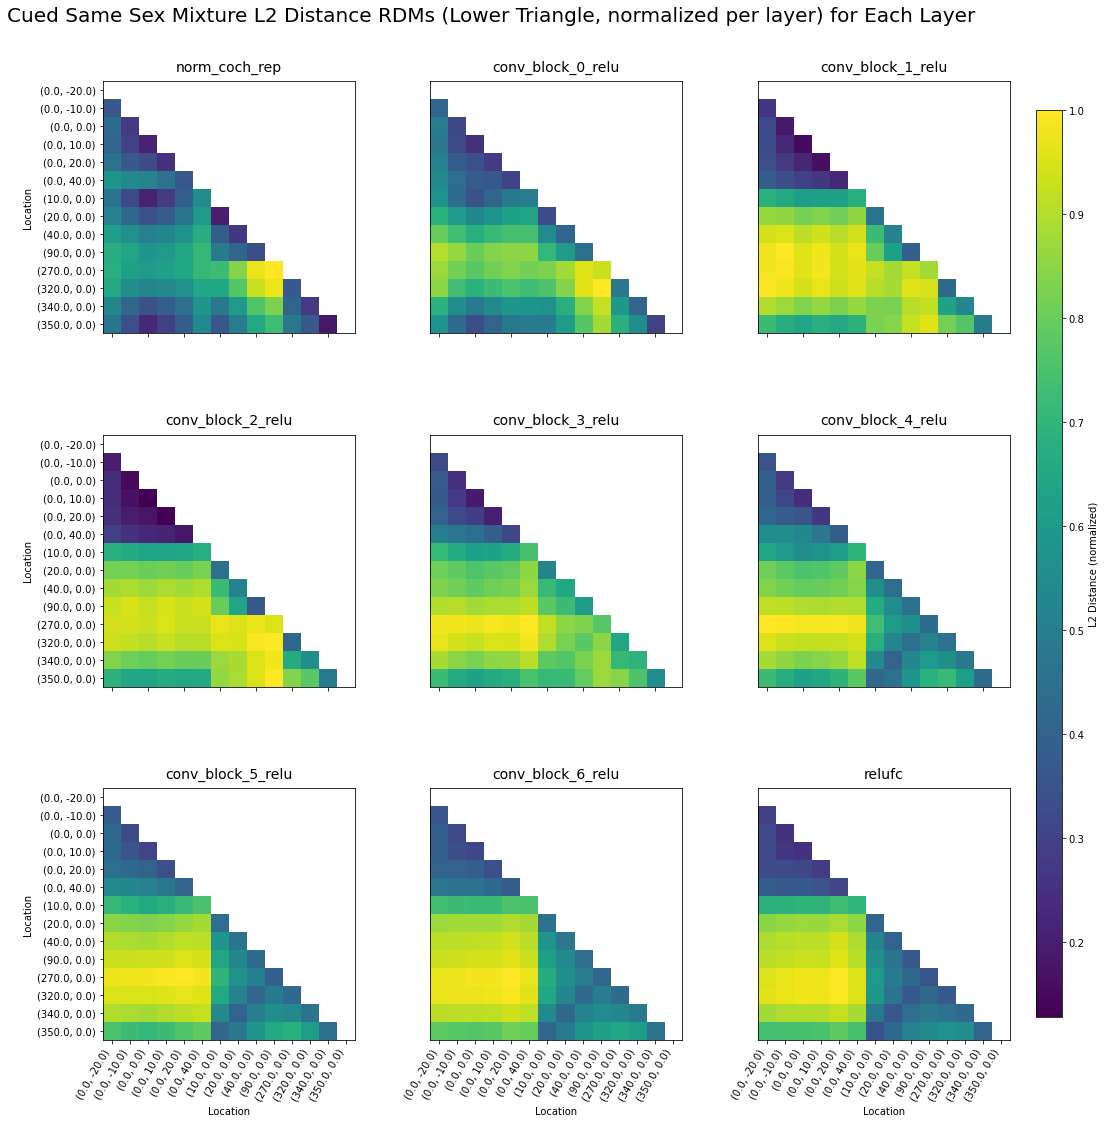

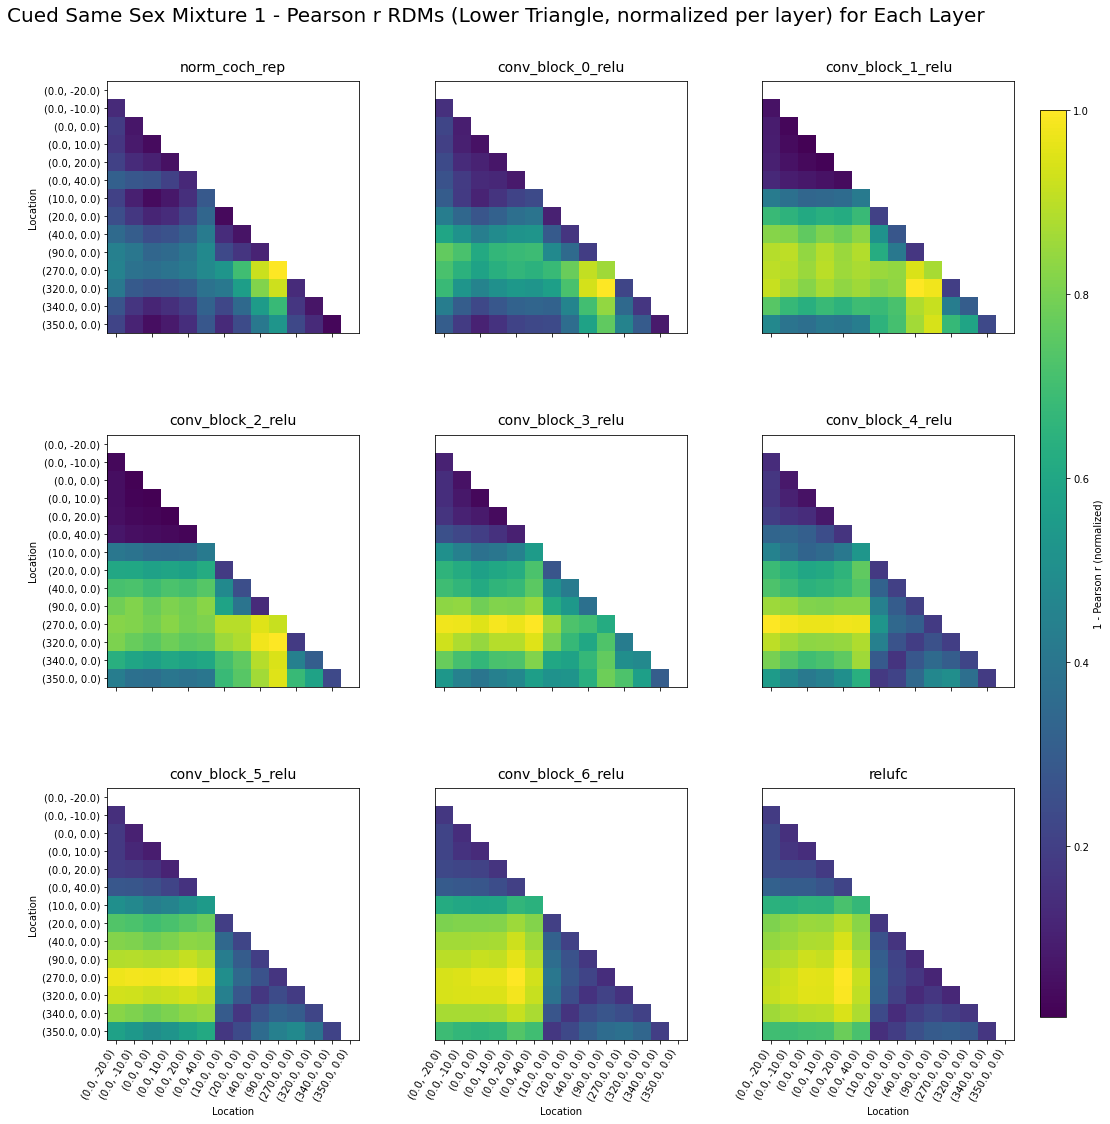

In [83]:
loc_labels = [str(loc) for loc in all_locs]

layers_of_interest = [
    'norm_coch_rep', 'conv_block_0_relu', 'conv_block_1_relu', 'conv_block_2_relu',
    'conv_block_3_relu', 'conv_block_4_relu', 'conv_block_5_relu', 'conv_block_6_relu', 'relufc'
]

# Precompute all RDMs for all layers, normalizing each matrix so its max is 1 (excluding diagonal for L2, and for Pearson)
l2_rdms = []
pearson_rdms = []
for layer in layers_of_interest:
    layer_reps = embeddings[f'{layer}_mixture_same_sex_cued']
    pearson_r_matrix = np.full((n, n), np.nan, dtype=float)
    l2_dist_matrix  = np.full((n, n), np.nan, dtype=float)
    for i in range(n):
        Xi = layer_reps[loc_to_idx[all_locs[i]]]  # (N, D)
        pearson_r_matrix[i, i] = 1.0
        l2_dist_matrix[i, i]   = 0.0
        for j in range(i):
            Xj = layer_reps[loc_to_idx[all_locs[j]]]  # (N, D)
            r  = pearson_r(Xi, Xj)
            d  = l2_dist(Xi, Xj)
            pearson_r_matrix[i, j] = pearson_r_matrix[j, i] = 1 - r
            l2_dist_matrix[i, j]   = l2_dist_matrix[j, i]   = d

    # Normalize L2 matrix (excluding diagonal)
    l2_mask = get_lower_triangle_mask(l2_dist_matrix)
    l2_vals = l2_dist_matrix[~l2_mask]
    l2_max = np.nanmax(l2_vals)
    if l2_max > 0:
        l2_dist_matrix = l2_dist_matrix / l2_max

    # Normalize Pearson matrix (excluding diagonal)
    pearson_mask = get_lower_triangle_mask(pearson_r_matrix)
    pearson_vals = pearson_r_matrix[~pearson_mask]
    pearson_max = np.nanmax(pearson_vals)
    if pearson_max > 0:
        pearson_r_matrix = pearson_r_matrix / pearson_max

    l2_rdms.append(l2_dist_matrix)
    pearson_rdms.append(pearson_r_matrix)

# Compute global vmin/vmax for each metric across all layers for consistent colorbars
def get_global_min_max(rdms, mask_func):
    vals = []
    for rdm in rdms:
        mask = mask_func(rdm)
        vals.append(np.ma.masked_array(rdm, mask=mask))
    all_vals = np.ma.concatenate([v.compressed() for v in vals])
    return np.nanmin(all_vals), np.nanmax(all_vals)

l2_vmin, l2_vmax = get_global_min_max(l2_rdms, get_lower_triangle_mask)
pearson_vmin, pearson_vmax = get_global_min_max(pearson_rdms, get_lower_triangle_mask)

# Plot 3x3 grid: each row is a layer, left=L2, right=1-Pearson r
fig, axes = plt.subplots(3, 3, figsize=(18, 18))
plt.subplots_adjust(wspace=0.3, hspace=0.3, left=0.20)  # 2) make room on the left


for idx, layer in enumerate(layers_of_interest):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    # L2 on top, Pearson on bottom
    l2_rdm = l2_rdms[idx]
    pearson_rdm = pearson_rdms[idx]
    mask = get_lower_triangle_mask(l2_rdm)
    l2_masked = np.ma.masked_array(l2_rdm, mask=mask)
    pearson_masked = np.ma.masked_array(pearson_rdm, mask=mask)
    # Plot L2 in left column, Pearson in right column
    im = ax.imshow(l2_masked, cmap='viridis', vmin=l2_vmin, vmax=l2_vmax)
    # Overlay 1-Pearson r as a second image with a different colormap if desired
    # im2 = ax.imshow(pearson_masked, cmap='magma', vmin=pearson_vmin, vmax=pearson_vmax, alpha=0.5)
    ax.set_title(f"{layer}", fontsize=14, pad=10)
    if row == 2:
        ax.set_xticks(np.arange(len(loc_labels)))
        ax.set_xticklabels(loc_labels, rotation=60, ha='right', fontsize=10)
    else:
        ax.set_xticklabels([])
    # Always set y-ticks and y-ticklabels for first column
    if col == 0:
        ax.set_yticks(np.arange(len(loc_labels)))
        ax.set_yticklabels(loc_labels, fontsize=10)
    else:
        ax.set_yticks([])  # Hide y-ticks for other columns
        ax.set_yticklabels([])
        ax.tick_params(labelleft=True, left=True)
    # Only label axes on left and bottom
    if row == 2:
        ax.set_xlabel("Location")
    if col == 0:
        ax.set_ylabel("Location")

# Add a single colorbar for L2
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label="L2 Distance (normalized)")

plt.suptitle("Cued Same Sex Mixture L2 Distance RDMs (Lower Triangle, normalized per layer) for Each Layer", fontsize=20, y=0.93)
plt.show()

# Now plot 3x3 grid for 1-Pearson r
fig, axes = plt.subplots(3, 3, figsize=(18, 18) )
plt.subplots_adjust(wspace=0.3, hspace=0.3, left=0.20)  # 2) make room on the left

for idx, layer in enumerate(layers_of_interest):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    pearson_rdm = pearson_rdms[idx]
    mask = get_lower_triangle_mask(pearson_rdm)
    pearson_masked = np.ma.masked_array(pearson_rdm, mask=mask)
    im = ax.imshow(pearson_masked, cmap='viridis', vmin=pearson_vmin, vmax=pearson_vmax)
    ax.set_title(f"{layer}", fontsize=14, pad=10)
    if row == 2:
        ax.set_xticks(np.arange(len(loc_labels)))
        ax.set_xticklabels(loc_labels, rotation=60, ha='right', fontsize=10)
    else:
        ax.set_xticklabels([])
    # Always set y-ticks and y-ticklabels for first column
    if col == 0:
        ax.set_yticks(np.arange(len(loc_labels)))
        ax.set_yticklabels(loc_labels, fontsize=10)
        ax.tick_params(labelleft=True, left=True)
    else:
        ax.set_yticks([])  # Hide y-ticks for other columns
        ax.set_yticklabels([])
    if row == 2:
        ax.set_xlabel("Location")
    if col == 0:
        ax.set_ylabel("Location")

# Add a single colorbar for 1-Pearson r
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label="1 - Pearson r (normalized)")

plt.suptitle("Cued Same Sex Mixture 1 - Pearson r RDMs (Lower Triangle, normalized per layer) for Each Layer", fontsize=20, y=0.93)
plt.show()

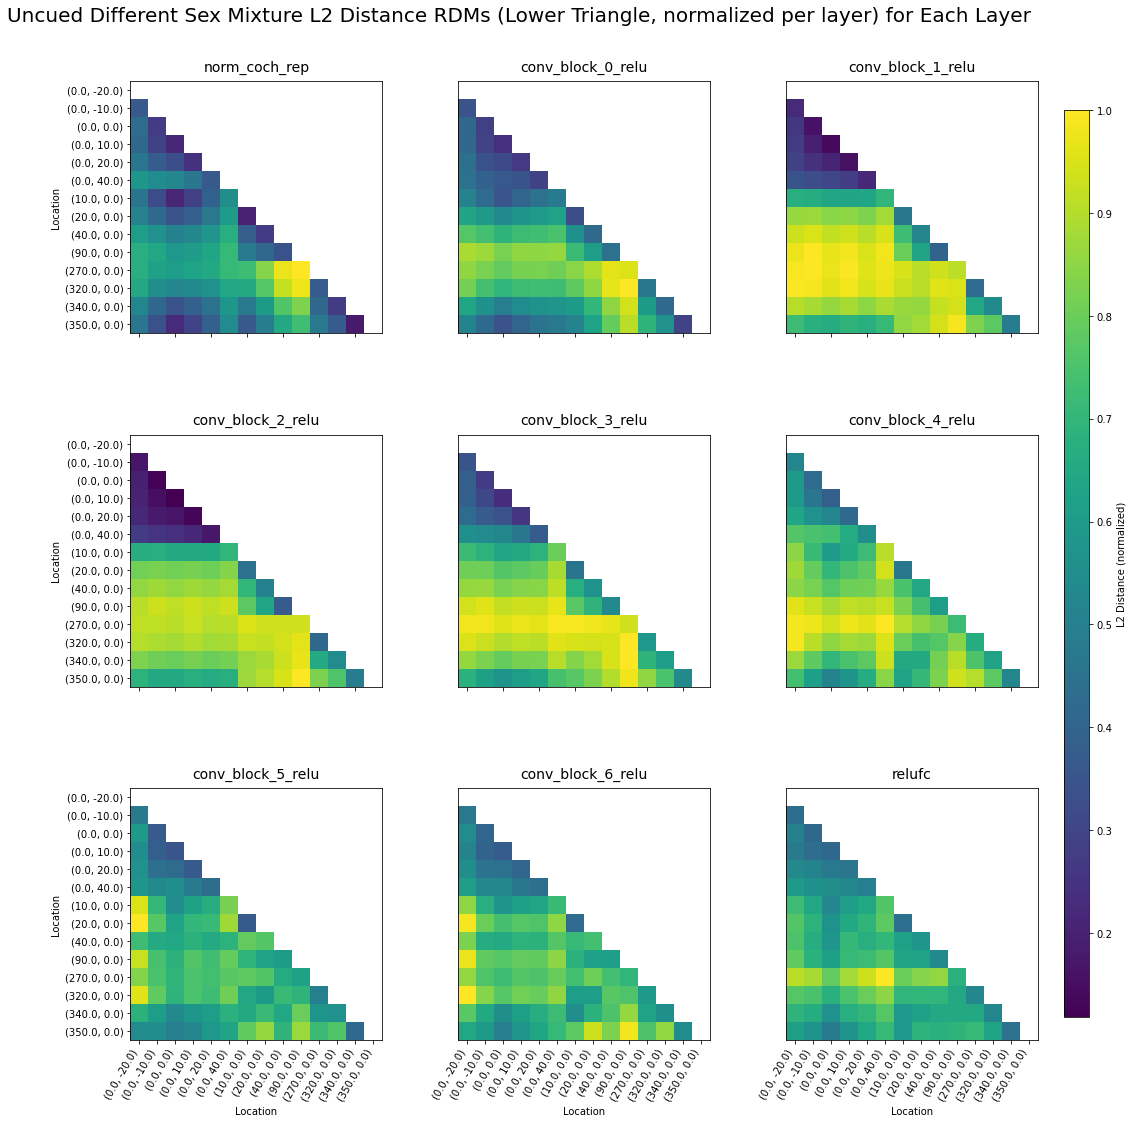

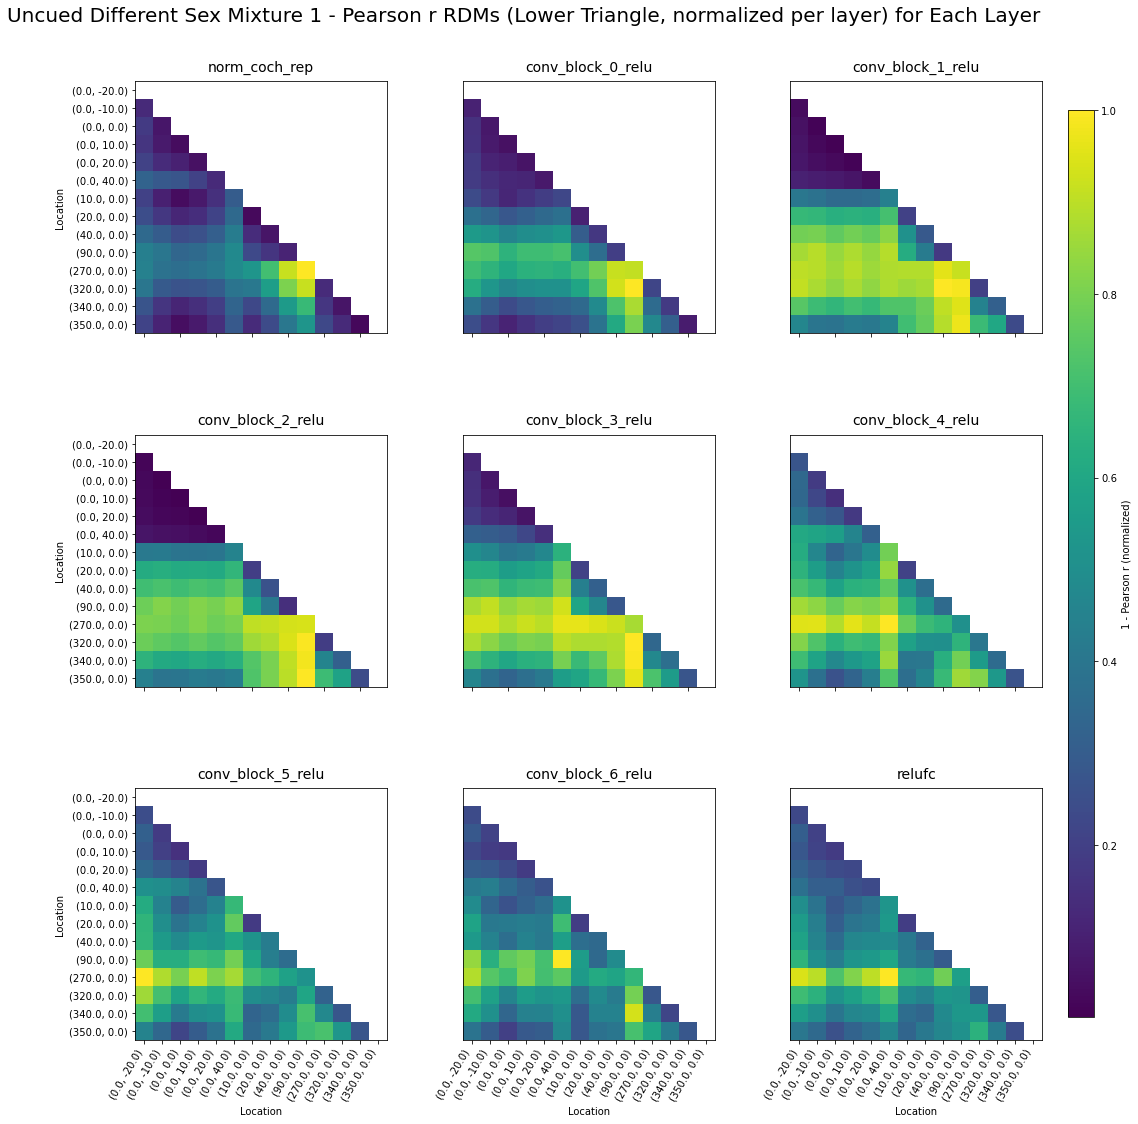

In [84]:
loc_labels = [str(loc) for loc in all_locs]

layers_of_interest = [
    'norm_coch_rep', 'conv_block_0_relu', 'conv_block_1_relu', 'conv_block_2_relu',
    'conv_block_3_relu', 'conv_block_4_relu', 'conv_block_5_relu', 'conv_block_6_relu', 'relufc'
]

# Precompute all RDMs for all layers, normalizing each matrix so its max is 1 (excluding diagonal for L2, and for Pearson)
l2_rdms = []
pearson_rdms = []
for layer in layers_of_interest:
    layer_reps = embeddings[f'{layer}_mixture_diff_sex_single_source']
    pearson_r_matrix = np.full((n, n), np.nan, dtype=float)
    l2_dist_matrix  = np.full((n, n), np.nan, dtype=float)
    for i in range(n):
        Xi = layer_reps[loc_to_idx[all_locs[i]]]  # (N, D)
        pearson_r_matrix[i, i] = 1.0
        l2_dist_matrix[i, i]   = 0.0
        for j in range(i):
            Xj = layer_reps[loc_to_idx[all_locs[j]]]  # (N, D)
            r  = pearson_r(Xi, Xj)
            d  = l2_dist(Xi, Xj)
            pearson_r_matrix[i, j] = pearson_r_matrix[j, i] = 1 - r
            l2_dist_matrix[i, j]   = l2_dist_matrix[j, i]   = d

    # Normalize L2 matrix (excluding diagonal)
    l2_mask = get_lower_triangle_mask(l2_dist_matrix)
    l2_vals = l2_dist_matrix[~l2_mask]
    l2_max = np.nanmax(l2_vals)
    if l2_max > 0:
        l2_dist_matrix = l2_dist_matrix / l2_max

    # Normalize Pearson matrix (excluding diagonal)
    pearson_mask = get_lower_triangle_mask(pearson_r_matrix)
    pearson_vals = pearson_r_matrix[~pearson_mask]
    pearson_max = np.nanmax(pearson_vals)
    if pearson_max > 0:
        pearson_r_matrix = pearson_r_matrix / pearson_max

    l2_rdms.append(l2_dist_matrix)
    pearson_rdms.append(pearson_r_matrix)

# Compute global vmin/vmax for each metric across all layers for consistent colorbars
def get_global_min_max(rdms, mask_func):
    vals = []
    for rdm in rdms:
        mask = mask_func(rdm)
        vals.append(np.ma.masked_array(rdm, mask=mask))
    all_vals = np.ma.concatenate([v.compressed() for v in vals])
    return np.nanmin(all_vals), np.nanmax(all_vals)

l2_vmin, l2_vmax = get_global_min_max(l2_rdms, get_lower_triangle_mask)
pearson_vmin, pearson_vmax = get_global_min_max(pearson_rdms, get_lower_triangle_mask)

# Plot 3x3 grid: each row is a layer, left=L2, right=1-Pearson r
fig, axes = plt.subplots(3, 3, figsize=(18, 18))
plt.subplots_adjust(wspace=0.3, hspace=0.3, left=0.20)  # 2) make room on the left


for idx, layer in enumerate(layers_of_interest):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    # L2 on top, Pearson on bottom
    l2_rdm = l2_rdms[idx]
    pearson_rdm = pearson_rdms[idx]
    mask = get_lower_triangle_mask(l2_rdm)
    l2_masked = np.ma.masked_array(l2_rdm, mask=mask)
    pearson_masked = np.ma.masked_array(pearson_rdm, mask=mask)
    # Plot L2 in left column, Pearson in right column
    im = ax.imshow(l2_masked, cmap='viridis', vmin=l2_vmin, vmax=l2_vmax)
    # Overlay 1-Pearson r as a second image with a different colormap if desired
    # im2 = ax.imshow(pearson_masked, cmap='magma', vmin=pearson_vmin, vmax=pearson_vmax, alpha=0.5)
    ax.set_title(f"{layer}", fontsize=14, pad=10)
    if row == 2:
        ax.set_xticks(np.arange(len(loc_labels)))
        ax.set_xticklabels(loc_labels, rotation=60, ha='right', fontsize=10)
    else:
        ax.set_xticklabels([])
    # Always set y-ticks and y-ticklabels for first column
    if col == 0:
        ax.set_yticks(np.arange(len(loc_labels)))
        ax.set_yticklabels(loc_labels, fontsize=10)
    else:
        ax.set_yticks([])  # Hide y-ticks for other columns
        ax.set_yticklabels([])
        ax.tick_params(labelleft=True, left=True)
    # Only label axes on left and bottom
    if row == 2:
        ax.set_xlabel("Location")
    if col == 0:
        ax.set_ylabel("Location")

# Add a single colorbar for L2
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label="L2 Distance (normalized)")

plt.suptitle("Uncued Different Sex Mixture L2 Distance RDMs (Lower Triangle, normalized per layer) for Each Layer", fontsize=20, y=0.93)
plt.show()

# Now plot 3x3 grid for 1-Pearson r
fig, axes = plt.subplots(3, 3, figsize=(18, 18) )
plt.subplots_adjust(wspace=0.3, hspace=0.3, left=0.20)  # 2) make room on the left

for idx, layer in enumerate(layers_of_interest):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    pearson_rdm = pearson_rdms[idx]
    mask = get_lower_triangle_mask(pearson_rdm)
    pearson_masked = np.ma.masked_array(pearson_rdm, mask=mask)
    im = ax.imshow(pearson_masked, cmap='viridis', vmin=pearson_vmin, vmax=pearson_vmax)
    ax.set_title(f"{layer}", fontsize=14, pad=10)
    if row == 2:
        ax.set_xticks(np.arange(len(loc_labels)))
        ax.set_xticklabels(loc_labels, rotation=60, ha='right', fontsize=10)
    else:
        ax.set_xticklabels([])
    # Always set y-ticks and y-ticklabels for first column
    if col == 0:
        ax.set_yticks(np.arange(len(loc_labels)))
        ax.set_yticklabels(loc_labels, fontsize=10)
        ax.tick_params(labelleft=True, left=True)
    else:
        ax.set_yticks([])  # Hide y-ticks for other columns
        ax.set_yticklabels([])
    if row == 2:
        ax.set_xlabel("Location")
    if col == 0:
        ax.set_ylabel("Location")

# Add a single colorbar for 1-Pearson r
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label="1 - Pearson r (normalized)")

plt.suptitle("Uncued Different Sex Mixture 1 - Pearson r RDMs (Lower Triangle, normalized per layer) for Each Layer", fontsize=20, y=0.93)
plt.show()

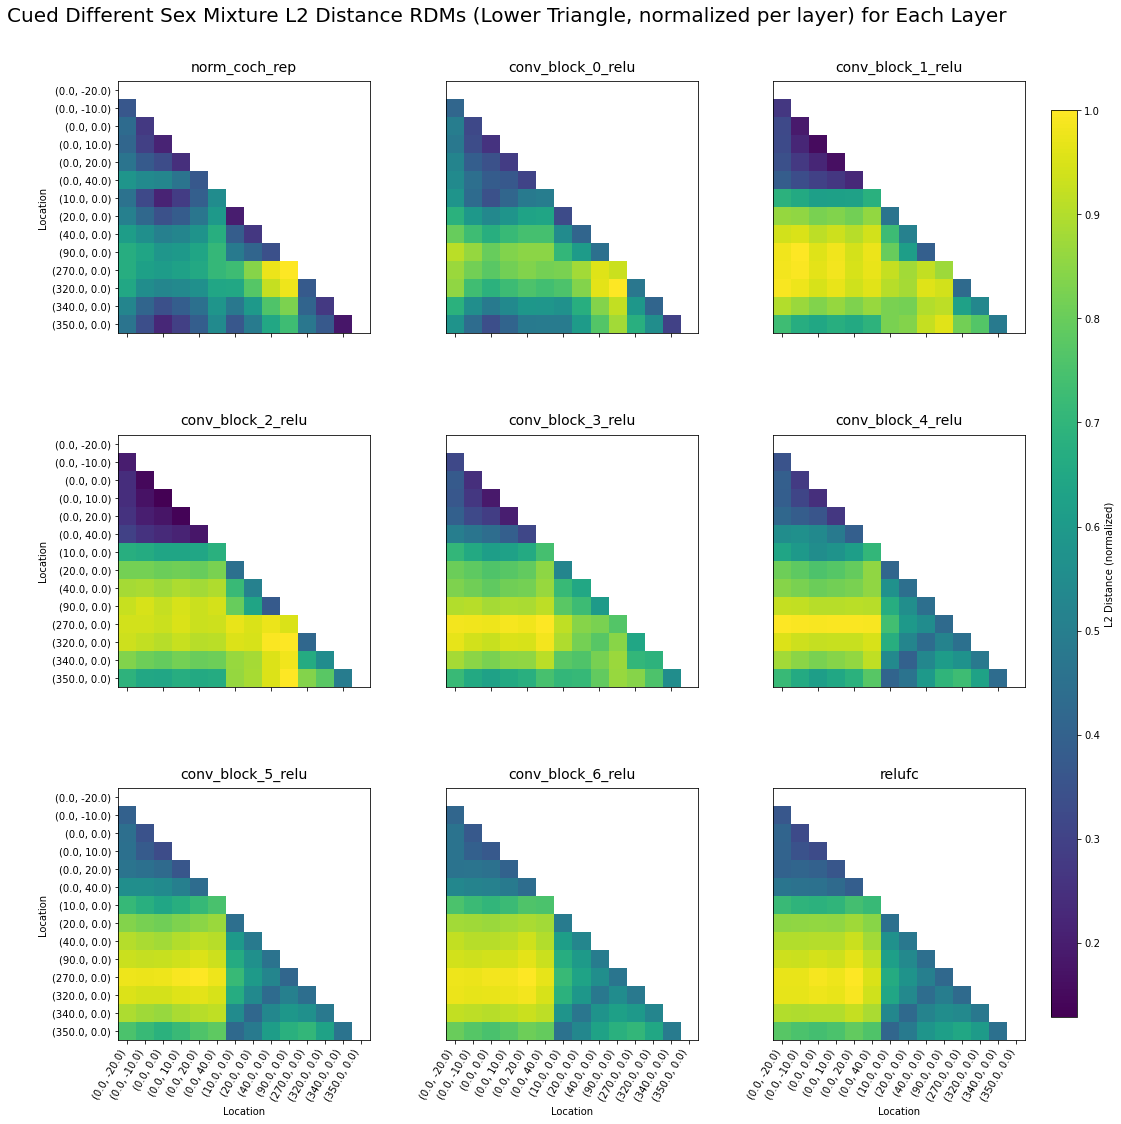

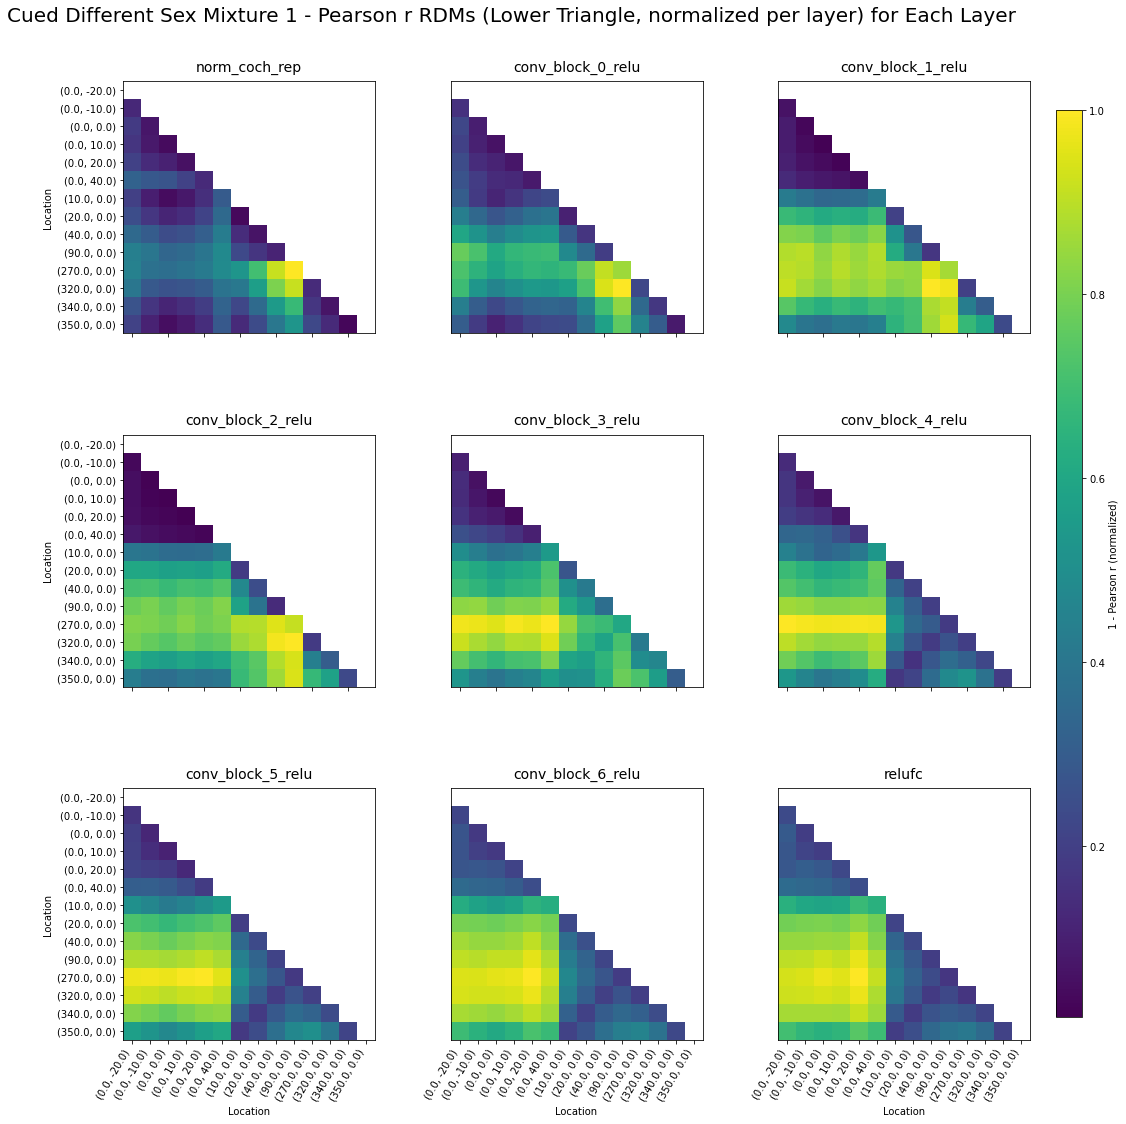

In [85]:
loc_labels = [str(loc) for loc in all_locs]

layers_of_interest = [
    'norm_coch_rep', 'conv_block_0_relu', 'conv_block_1_relu', 'conv_block_2_relu',
    'conv_block_3_relu', 'conv_block_4_relu', 'conv_block_5_relu', 'conv_block_6_relu', 'relufc'
]

# Precompute all RDMs for all layers, normalizing each matrix so its max is 1 (excluding diagonal for L2, and for Pearson)
l2_rdms = []
pearson_rdms = []
for layer in layers_of_interest:
    layer_reps = embeddings[f'{layer}_mixture_diff_sex_cued']
    pearson_r_matrix = np.full((n, n), np.nan, dtype=float)
    l2_dist_matrix  = np.full((n, n), np.nan, dtype=float)
    for i in range(n):
        Xi = layer_reps[loc_to_idx[all_locs[i]]]  # (N, D)
        pearson_r_matrix[i, i] = 1.0
        l2_dist_matrix[i, i]   = 0.0
        for j in range(i):
            Xj = layer_reps[loc_to_idx[all_locs[j]]]  # (N, D)
            r  = pearson_r(Xi, Xj)
            d  = l2_dist(Xi, Xj)
            pearson_r_matrix[i, j] = pearson_r_matrix[j, i] = 1 - r
            l2_dist_matrix[i, j]   = l2_dist_matrix[j, i]   = d

    # Normalize L2 matrix (excluding diagonal)
    l2_mask = get_lower_triangle_mask(l2_dist_matrix)
    l2_vals = l2_dist_matrix[~l2_mask]
    l2_max = np.nanmax(l2_vals)
    if l2_max > 0:
        l2_dist_matrix = l2_dist_matrix / l2_max

    # Normalize Pearson matrix (excluding diagonal)
    pearson_mask = get_lower_triangle_mask(pearson_r_matrix)
    pearson_vals = pearson_r_matrix[~pearson_mask]
    pearson_max = np.nanmax(pearson_vals)
    if pearson_max > 0:
        pearson_r_matrix = pearson_r_matrix / pearson_max

    l2_rdms.append(l2_dist_matrix)
    pearson_rdms.append(pearson_r_matrix)

# Compute global vmin/vmax for each metric across all layers for consistent colorbars
def get_global_min_max(rdms, mask_func):
    vals = []
    for rdm in rdms:
        mask = mask_func(rdm)
        vals.append(np.ma.masked_array(rdm, mask=mask))
    all_vals = np.ma.concatenate([v.compressed() for v in vals])
    return np.nanmin(all_vals), np.nanmax(all_vals)

l2_vmin, l2_vmax = get_global_min_max(l2_rdms, get_lower_triangle_mask)
pearson_vmin, pearson_vmax = get_global_min_max(pearson_rdms, get_lower_triangle_mask)

# Plot 3x3 grid: each row is a layer, left=L2, right=1-Pearson r
fig, axes = plt.subplots(3, 3, figsize=(18, 18))
plt.subplots_adjust(wspace=0.3, hspace=0.3, left=0.20)  # 2) make room on the left


for idx, layer in enumerate(layers_of_interest):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    # L2 on top, Pearson on bottom
    l2_rdm = l2_rdms[idx]
    pearson_rdm = pearson_rdms[idx]
    mask = get_lower_triangle_mask(l2_rdm)
    l2_masked = np.ma.masked_array(l2_rdm, mask=mask)
    pearson_masked = np.ma.masked_array(pearson_rdm, mask=mask)
    # Plot L2 in left column, Pearson in right column
    im = ax.imshow(l2_masked, cmap='viridis', vmin=l2_vmin, vmax=l2_vmax)
    # Overlay 1-Pearson r as a second image with a different colormap if desired
    # im2 = ax.imshow(pearson_masked, cmap='magma', vmin=pearson_vmin, vmax=pearson_vmax, alpha=0.5)
    ax.set_title(f"{layer}", fontsize=14, pad=10)
    if row == 2:
        ax.set_xticks(np.arange(len(loc_labels)))
        ax.set_xticklabels(loc_labels, rotation=60, ha='right', fontsize=10)
    else:
        ax.set_xticklabels([])
    # Always set y-ticks and y-ticklabels for first column
    if col == 0:
        ax.set_yticks(np.arange(len(loc_labels)))
        ax.set_yticklabels(loc_labels, fontsize=10)
    else:
        ax.set_yticks([])  # Hide y-ticks for other columns
        ax.set_yticklabels([])
        ax.tick_params(labelleft=True, left=True)
    # Only label axes on left and bottom
    if row == 2:
        ax.set_xlabel("Location")
    if col == 0:
        ax.set_ylabel("Location")

# Add a single colorbar for L2
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label="L2 Distance (normalized)")

plt.suptitle("Cued Different Sex Mixture L2 Distance RDMs (Lower Triangle, normalized per layer) for Each Layer", fontsize=20, y=0.93)
plt.show()

# Now plot 3x3 grid for 1-Pearson r
fig, axes = plt.subplots(3, 3, figsize=(18, 18) )
plt.subplots_adjust(wspace=0.3, hspace=0.3, left=0.20)  # 2) make room on the left

for idx, layer in enumerate(layers_of_interest):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    pearson_rdm = pearson_rdms[idx]
    mask = get_lower_triangle_mask(pearson_rdm)
    pearson_masked = np.ma.masked_array(pearson_rdm, mask=mask)
    im = ax.imshow(pearson_masked, cmap='viridis', vmin=pearson_vmin, vmax=pearson_vmax)
    ax.set_title(f"{layer}", fontsize=14, pad=10)
    if row == 2:
        ax.set_xticks(np.arange(len(loc_labels)))
        ax.set_xticklabels(loc_labels, rotation=60, ha='right', fontsize=10)
    else:
        ax.set_xticklabels([])
    # Always set y-ticks and y-ticklabels for first column
    if col == 0:
        ax.set_yticks(np.arange(len(loc_labels)))
        ax.set_yticklabels(loc_labels, fontsize=10)
        ax.tick_params(labelleft=True, left=True)
    else:
        ax.set_yticks([])  # Hide y-ticks for other columns
        ax.set_yticklabels([])
    if row == 2:
        ax.set_xlabel("Location")
    if col == 0:
        ax.set_ylabel("Location")

# Add a single colorbar for 1-Pearson r
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label="1 - Pearson r (normalized)")

plt.suptitle("Cued Different Sex Mixture 1 - Pearson r RDMs (Lower Triangle, normalized per layer) for Each Layer", fontsize=20, y=0.93)
plt.show()